<a href="https://colab.research.google.com/github/ashycoding/Deep-Learning-Labs/blob/main/lab4_imdb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Import Dataset

In [1]:
import numpy as np
from tensorflow import keras
from tensorflow.keras.datasets import imdb

# vocab limit
vocab_size = 10000

# load data
(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=vocab_size)

Preprocessing : Padding

In [2]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

# fixed length
maxlen = 200

# pad sequences
x_train = pad_sequences(x_train, maxlen=maxlen)
x_test = pad_sequences(x_test, maxlen=maxlen)

Build LSTM Model

In [3]:
from tensorflow.keras import layers

model = keras.Sequential([
    layers.Embedding(10000, 128, input_length=200),

    layers.Bidirectional(layers.GRU(64, return_sequences=True)),
    layers.BatchNormalization(),
    layers.Dropout(0.5),

    layers.Bidirectional(layers.GRU(32)),
    layers.BatchNormalization(),
    layers.Dropout(0.5),

    layers.Dense(1, activation='sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Compile + Train

In [8]:
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import SGD

model.compile(
    optimizer=SGD(learning_rate=0.01, momentum=0.9),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

history=model.fit(
    x_train, y_train,
    epochs=15,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop]
)

Epoch 1/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 15s 37ms/step - accuracy: 0.9439 - loss: 0.1545 - val_accuracy: 0.6596 - val_loss: 1.3427
Epoch 2/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 11s 34ms/step - accuracy: 0.9506 - loss: 0.1357 - val_accuracy: 0.8556 - val_loss: 0.4205
Epoch 3/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 11s 35ms/step - accuracy: 0.9556 - loss: 0.1229 - val_accuracy: 0.8798 - val_loss: 0.3295
Epoch 4/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 11s 36ms/step - accuracy: 0.9592 - loss: 0.1124 - val_accuracy: 0.8024 - val_loss: 0.8442
Epoch 5/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 11s 34ms/step - accuracy: 0.9646 - loss: 0.0970 - val_accuracy: 0.8698 - val_loss: 0.3969


Evaluate

In [9]:
# test performance
loss, acc = model.evaluate(x_test, y_test)

print("Accuracy:", acc*100 ," %")

782/782 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - accuracy: 0.8758 - loss: 0.3379
Accuracy: 87.58400082588196  %


782/782 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step


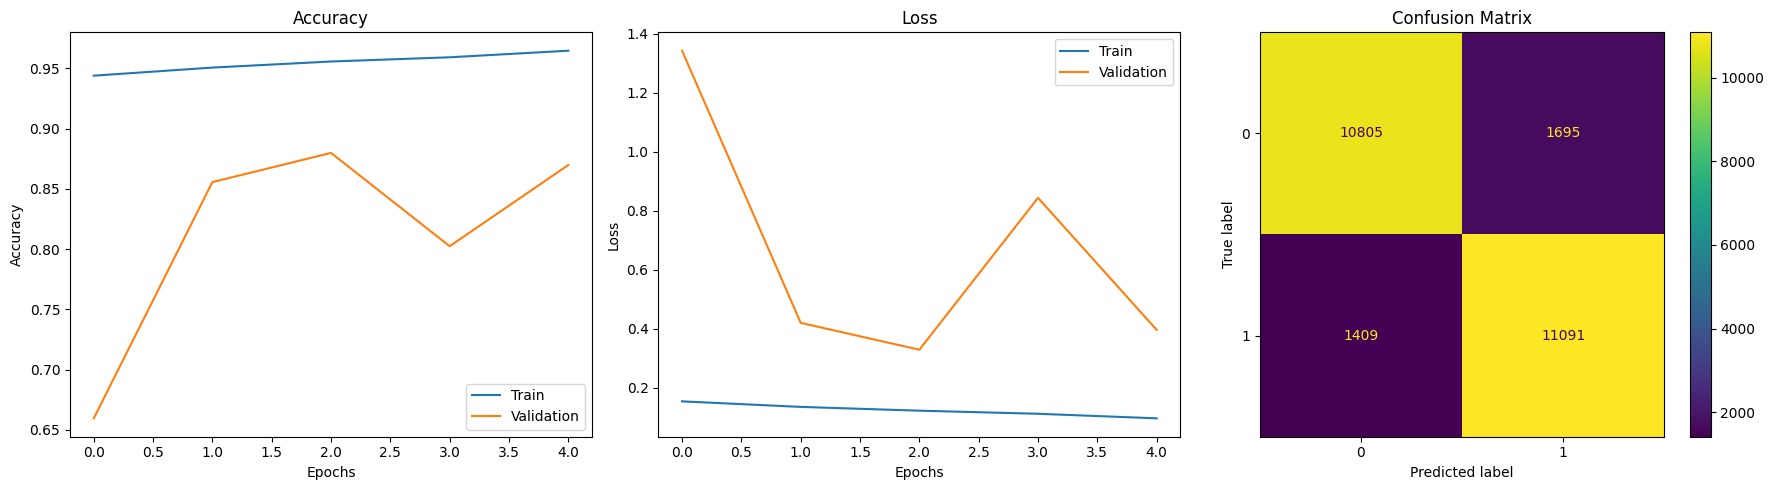

In [11]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Predictions for confusion matrix
y_pred = (model.predict(x_test) > 0.5).astype("int32")
cm = confusion_matrix(y_test, y_pred)

# Create horizontal layout (1 row, 3 columns)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# =======================
# 📈 Accuracy Graph
# =======================
axes[0].plot(history.history['accuracy'])
axes[0].plot(history.history['val_accuracy'])
axes[0].set_title('Accuracy')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Accuracy')
axes[0].legend(['Train', 'Validation'])

# =======================
# 📉 Loss Graph
# =======================
axes[1].plot(history.history['loss'])
axes[1].plot(history.history['val_loss'])
axes[1].set_title('Loss')
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Loss')
axes[1].legend(['Train', 'Validation'])

# =======================
# 🎯 Confusion Matrix
# =======================
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(ax=axes[2])
axes[2].set_title('Confusion Matrix')

plt.tight_layout()
plt.show()